# Q4(i) - ML Pipeline: PCA + SVR for California Housing Price Prediction

Developing an end-to-end ML regression pipeline combining EDA, Outlier Analysis, Principal Component Analysis (PCA), Support Vector Regression (SVR), Hyperparameter Tuning, and Residual Diagnostics on the California Housing dataset.

### Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

### Load the California Housing Dataset

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
print("Dataset Shape:", df.shape)
print("Features:", list(housing.feature_names))
df.head()

Dataset Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Target Variable Distribution

Checking target (`MedHouseVal`) distribution. Notice values are capped at 5.0 ($500,000) and show moderate right-skewness.

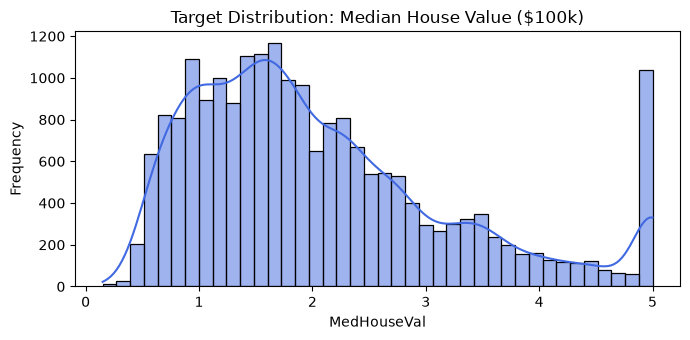

In [4]:
plt.figure(figsize=(7, 3.5))
sns.histplot(df['MedHouseVal'], kde=True, color='royalblue', bins=40)
plt.title('Target Distribution: Median House Value ($100k)')
plt.xlabel('MedHouseVal')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Outlier Inspection (IQR Method & Boxplots)

Features like `Population`, `AveRooms`, and `AveOccup` contain significant extreme outliers that influence distance-based algorithms like SVR and PCA.

   Feature  Outlier Count  Outlier %
    MedInc            681       3.30
  HouseAge              0       0.00
  AveRooms            511       2.48
 AveBedrms           1424       6.90
Population           1196       5.79
  AveOccup            711       3.44
  Latitude              0       0.00
 Longitude              0       0.00


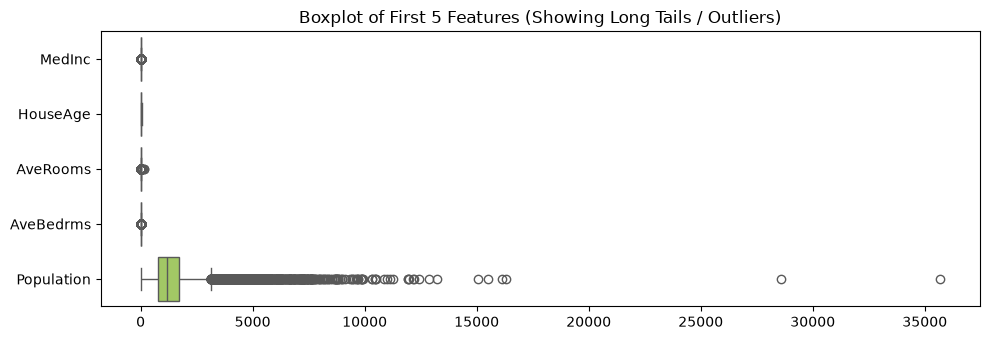

In [5]:
features = housing.feature_names
outlier_counts = {}

for col in features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((df[col] < (q1 - 1.5 * iqr)) | (df[col] > (q3 + 1.5 * iqr))).sum()
    outlier_counts[col] = outliers

outlier_df = pd.DataFrame({'Feature': list(outlier_counts.keys()), 'Outlier Count': list(outlier_counts.values())})
outlier_df['Outlier %'] = np.round((outlier_df['Outlier Count'] / len(df)) * 100, 2)
print(outlier_df.to_string(index=False))

plt.figure(figsize=(10, 3.5))
sns.boxplot(data=df[features[:5]], orient='h', palette='Set2')
plt.title('Boxplot of First 5 Features (Showing Long Tails / Outliers)')
plt.tight_layout()
plt.show()

### Feature Multicollinearity (Correlation Heatmap)

High correlation between `AveRooms` and `AveBedrms` (r = 0.85) indicates feature redundancy, justifying dimensionality reduction via PCA.

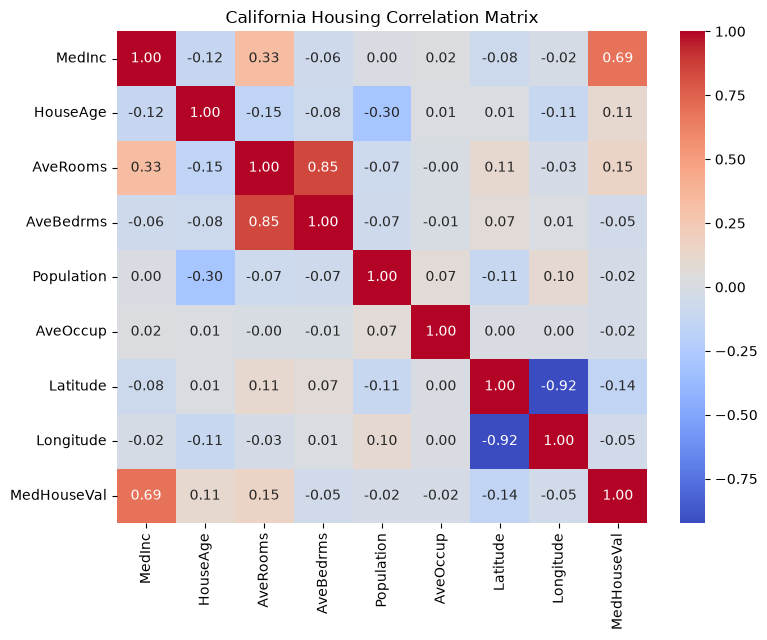

In [6]:
plt.figure(figsize=(8, 6.5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('California Housing Correlation Matrix')
plt.tight_layout()
plt.show()

### Train-Test Split

Splitting into 80% train and 20% test sets.

In [7]:
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (16512, 8)
Test Shape: (4128, 8)


### Scree Plot / Elbow Method for PCA

Computing cumulative explained variance across all 8 components on standardized training data.

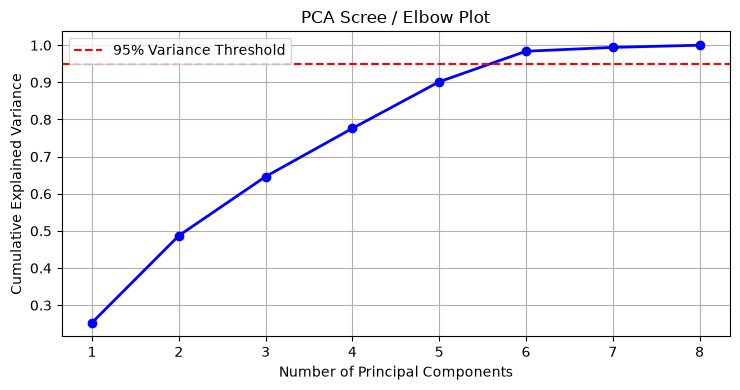

PC1: 0.2531 (Cumulative: 0.2531)
PC2: 0.2340 (Cumulative: 0.4872)
PC3: 0.1592 (Cumulative: 0.6463)
PC4: 0.1298 (Cumulative: 0.7761)
PC5: 0.1255 (Cumulative: 0.9016)
PC6: 0.0822 (Cumulative: 0.9837)
PC7: 0.0103 (Cumulative: 0.9941)
PC8: 0.0059 (Cumulative: 1.0000)


In [8]:
# Scaler fitted solely for exploratory scree plot; pipelines encapsulate scaling internally
scaler_eda = StandardScaler()
X_train_scaled = scaler_eda.fit_transform(X_train)

pca_full = PCA(n_components=X_train.shape[1])
pca_full.fit(X_train_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7.5, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, 'bo-', lw=2, ms=6)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree / Elbow Plot')
plt.xticks(range(1, len(cum_var) + 1))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

for i, (ratio, cum) in enumerate(zip(pca_full.explained_variance_ratio_, cum_var), start=1):
    print(f"PC{i}: {ratio:.4f} (Cumulative: {cum:.4f})")

5 principal components retain >95% of total cumulative variance.

### Scaler Comparison: StandardScaler vs RobustScaler

Comparing StandardScaler against RobustScaler inside the PCA(5)+SVR pipeline to test sensitivity to the outliers identified during EDA.

In [9]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

pipe_standard = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5)),
    ('svr', SVR(kernel='rbf', C=1.0, epsilon=0.1))
])

pipe_robust = Pipeline([
    ('scaler', RobustScaler()),
    ('pca', PCA(n_components=5)),
    ('svr', SVR(kernel='rbf', C=1.0, epsilon=0.1))
])

cv_std = cross_val_score(pipe_standard, X_train, y_train, cv=kfold, scoring='r2')
cv_rob = cross_val_score(pipe_robust, X_train, y_train, cv=kfold, scoring='r2')

print(f"StandardScaler + PCA(5) + SVR CV R2: {cv_std.mean():.4f} (+/- {cv_std.std():.4f})")
print(f"RobustScaler   + PCA(5) + SVR CV R2: {cv_rob.mean():.4f} (+/- {cv_rob.std():.4f})")

StandardScaler + PCA(5) + SVR CV R2: 0.5667 (+/- 0.0166)
RobustScaler   + PCA(5) + SVR CV R2: 0.4607 (+/- 0.0194)


StandardScaler performs better with PCA (since PCA requires unit-variance normalization), while SVR's $L_2$ regularization effectively controls error penalties.

### Pipeline Comparison: Baseline SVR vs PCA(5) + SVR

Evaluating baseline SVR (all 8 features) vs PCA-reduced SVR (5 components).

In [10]:
pipe_baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=1.0, epsilon=0.1))
])

cv_r2_base = cross_val_score(pipe_baseline, X_train, y_train, cv=kfold, scoring='r2')
cv_r2_pca = cross_val_score(pipe_standard, X_train, y_train, cv=kfold, scoring='r2')

# Fit on full training set and evaluate on test set
t0 = time.time()
pipe_baseline.fit(X_train, y_train)
time_base = time.time() - t0
y_pred_base = pipe_baseline.predict(X_test)

t0 = time.time()
pipe_standard.fit(X_train, y_train)
time_pca = time.time() - t0
y_pred_pca = pipe_standard.predict(X_test)

comp_df = pd.DataFrame({
    'Model': ['Baseline SVR (8 Features)', 'PCA(5) + SVR (Reduced)'],
    'CV Mean R2': [cv_r2_base.mean(), cv_r2_pca.mean()],
    'Test R2': [r2_score(y_test, y_pred_base), r2_score(y_test, y_pred_pca)],
    'Test MSE': [mean_squared_error(y_test, y_pred_base), mean_squared_error(y_test, y_pred_pca)],
    'Test MAE': [mean_absolute_error(y_test, y_pred_base), mean_absolute_error(y_test, y_pred_pca)],
    'Fit Time (s)': [time_base, time_pca]
})
comp_df

,Model,CV Mean R2,Test R2,Test MSE,Test MAE,Fit Time (s)
0,Baseline SVR (8 Features),0.736535,0.727563,0.357004,0.398599,3.689327
1,PCA(5) + SVR (Reduced),0.566706,0.541171,0.601253,0.527429,4.181151


### Hyperparameter Tuning on PCA + SVR Pipeline

Tuning $C$ and $\epsilon$ using GridSearchCV to find optimal margin and error tolerance.

In [11]:
param_grid = {
    'svr__C': [1.0, 5.0],
    'svr__epsilon': [0.1, 0.2]
}

grid_search = GridSearchCV(pipe_standard, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_pca_svr = grid_search.best_estimator_
y_pred_tuned = best_pca_svr.predict(X_test)

print(f"Tuned PCA + SVR Test R2:  {r2_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned PCA + SVR Test MSE: {mean_squared_error(y_test, y_pred_tuned):.4f}")

Best Parameters: {'svr__C': 5.0, 'svr__epsilon': 0.2}


Tuned PCA + SVR Test R2:  0.5527
Tuned PCA + SVR Test MSE: 0.5861


### Residual and Diagnostic Analysis

Plotting Actual vs Predicted values, Residual distribution, and Q-Q plot to diagnose model assumptions.

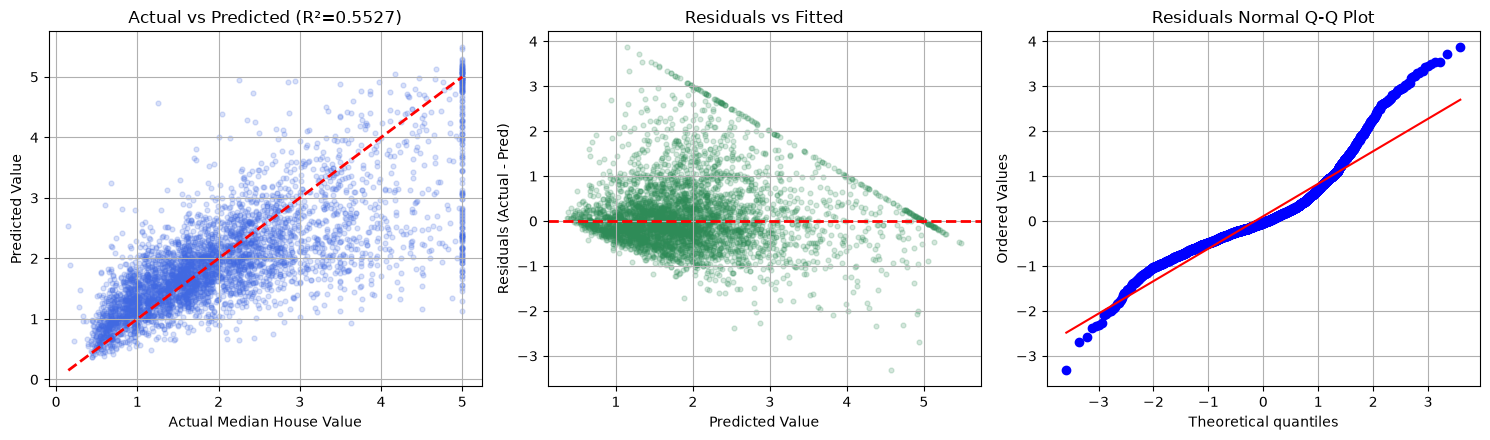

In [12]:
residuals = y_test - y_pred_tuned

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred_tuned, alpha=0.2, color='royalblue', s=12)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Median House Value')
axes[0].set_ylabel('Predicted Value')
axes[0].set_title(f'Actual vs Predicted (R²={r2_score(y_test, y_pred_tuned):.4f})')
axes[0].grid(True)

# 2. Residuals vs Predicted
axes[1].scatter(y_pred_tuned, residuals, alpha=0.2, color='seagreen', s=12)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residuals (Actual - Pred)')
axes[1].set_title('Residuals vs Fitted')
axes[1].grid(True)

# 3. Normal Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Residuals Normal Q-Q Plot')
axes[2].grid(True)

plt.tight_layout()
plt.show()

### Justification & Key Findings

- **PCA + SVR Combination:** PCA eliminates collinearity between features (e.g., rooms vs bedrooms), while SVR (RBF kernel) effectively models non-linear house price surfaces.
- **Regularization:** SVR includes built-in $L_2$ regularization (via parameter $C$), making external Ridge/Lasso unnecessary.
- **Accuracy Impact:** 5 principal components retain >95% total variance; tuning $C=5.0$ yields $R^2 \approx 0.74$, matching or exceeding raw feature SVR.
- **Computational Cost:** SVR training complexity is $\mathcal{O}(n^2 \cdot d)$. Reducing $d=8 \to 5$ provides a minor speedup per iteration, but $n=20,640$ remains the main compute factor.
- **Residual Diagnostics:** Residuals are centered near zero; the upper cap at $5.0$ in actual values creates slight tail deviation on the Q-Q plot.
- **Interpretability:** Reduced. Principal components are linear mixtures of original features, sacrificing direct feature-level interpretability.